# 🦺 YOLO26 PPE Detection — 11-Class Training (COCO Pretrained)

**Classes (11):** Hardhat · Mask · NO-Hardhat · NO-Mask · NO-Safety Vest · Person · Safety Vest · Safety-boots · NO-Safety-boots · Gloves · NO-Gloves  
**Pretrained weight:** `yolo26l.pt` — COCO-pretrained (80 classes, 118K images). The backbone has already learned rich visual features (edges, textures, shapes, objects) that transfer well to PPE detection.  
**Model:** YOLO26 (NMS-free head, MuSGD optimiser, improved small-object detection)  
**Hardware:** Google Colab A100 (40 GB VRAM)  
**Strategy:** Two-phase transfer learning — frozen backbone warmup → full fine-tune with strong generalisation  
**Background images:** 454 hard-negative images added to train to reduce false positives  

---
## 📋 Run Order

| Section | When to run |
|---|---|
| **0 — Setup** | Every session (always first) |
| **1 — Configuration** | Every session (set your Drive paths here) |
| **2 — Dataset Prep** | Every session (auto-skips if already done) |
| **3 — Verify Dataset** | Once — confirm class distribution + BG count |
| **A1 — Phase 1** | First time only — frozen backbone (30 epochs) |
| **A2 — Phase 2** | After Phase 1 — full fine-tune (100 epochs max) |
| **B — Resume** | After any crash or disconnect |
| **4 — Monitor** | Any time — plot loss curves + mAP |
| **5 — Evaluate** | After training — per-class AP on test set |
| **6 — Export** | After training — ONNX / TensorRT |

> **Important:** Sections A1 and A2 each have an overwrite guard.  
> If you accidentally re-run them, they will stop before overwriting anything.

---
### Why COCO pretrained helps
`yolo26l.pt` was trained on the COCO dataset (80 classes, ~118K images).  
The backbone already recognises general object features — body shapes, clothing, hard edges — that are directly relevant to PPE detection.  
When fine-tuned on the 11-class PPE dataset, this means:
- All 11 classes converge faster compared to random initialisation.
- The backbone generalises better, especially for rare classes (NO-boots, NO-Gloves) that have fewer training samples.
- Using the universal COCO weights avoids the instability of loading mismatched class-head weights from a domain-specific model.


---
## ⚙️ Section 0 — Setup
> **Always run this first at the start of every Colab session.**  
> Mounts Google Drive, installs Ultralytics, confirms A100.


In [1]:
# ── Verify GPU — should say A100 40GB ─────────────────────────────
!nvidia-smi | head -20

# ── Mount Google Drive ────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# ── Install / upgrade Ultralytics (YOLO26 requires >= 8.3) ───────
!pip install ultralytics -q --upgrade

# ── Confirm ───────────────────────────────────────────────────────
import ultralytics
ultralytics.checks()


Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
Setup complete ✅ (12 CPUs, 83.5 GB RAM, 42.9/112.6 GB disk)


---
## 🔧 Section 1 — Configuration
> **Always run this every session.**  
> Edit only inside the `USER CONFIG` block.


In [2]:
import os

# ═══════════════════════════════════════════════════════════════════
#  USER CONFIG — edit only this block
# ═══════════════════════════════════════════════════════════════════

DRIVE_DATASET_PATH = '/content/drive/MyDrive/FINALE/MERGED_DATASET'
# Folder on Drive containing:
#   train/images/  train/labels/   (5014 images — 11 classes, Goggles removed)
#   valid/images/  valid/labels/   (625 images)
#   test/images/   test/labels/    (628 images)
#   background_images/             (454 hard-negative BG images)

DRIVE_RESULTS_PATH = '/content/drive/MyDrive/FINALE/Runs'
# Folder on Drive where all checkpoints + results will be saved
# (created automatically if it does not exist)

RUN_NAME = 'yolo26_ppe_11cls_v1'
# Unique name for this experiment.
# Change this for each new run to avoid overwriting old results.

MODEL_SIZE = 'l'
# YOLO26 variant: 'n' (nano) | 's' (small) | 'm' (medium) | 'l' (large) | 'x' (xlarge)
# 'l' is recommended — best accuracy/speed balance for A100
MODEL_PT = 'yolo26' + MODEL_SIZE + '.pt'
# Auto-downloads COCO-pretrained weights from Ultralytics hub on first run

PHASE1_EPOCHS = 30
# Frozen-backbone warmup — head learns all 11-class embeddings rapidly.
# Do NOT reduce below 20.

PHASE2_EPOCHS = 100
# Full fine-tune maximum epochs.
# Early stopping (patience=25) will cut short when mAP plateaus.
# 100 epochs is achievable in ~3-4 hours on A100 at imgsz=1280.

IMGSZ = 1280
# Recommended: many small PPE objects (boots, masks, gloves).
# Drop to 640 if OOM — unlikely on A100 with yolo26l.

BATCH = -1
# -1 = auto-detect optimal batch for available VRAM (recommended)
# A100 40GB typically picks 32-64 at imgsz=1280
# Set explicitly e.g. BATCH = 16 if auto fails.

# ═══════════════════════════════════════════════════════════════════

ALL_NAMES = [
    'Hardhat',         # 0
    'Mask',            # 1
    'NO-Hardhat',      # 2
    'NO-Mask',         # 3
    'NO-Safety Vest',  # 4
    'Person',          # 5
    'Safety Vest',     # 6
    'Safety-boots',    # 7
    'NO-Safety-boots', # 8
    'Gloves',          # 9
    'NO-Gloves',       # 10
    # Goggles (11) and NO-Goggles (12) removed — too few/noisy samples
]

DATA_YAML = '/content/dataset/data.yaml'

os.makedirs(DRIVE_RESULTS_PATH, exist_ok=True)

print('=' * 66)
print('  Run name       :', RUN_NAME)
print('  Pretrained     :', MODEL_PT, '(COCO pretrained — auto-downloaded)')
print('  Drive dataset  :', DRIVE_DATASET_PATH)
print('  Drive results  :', DRIVE_RESULTS_PATH)
print('  Classes        : 11  (Goggles + NO-Goggles removed)')
print('  Image size     :', IMGSZ)
print('  Batch          :', BATCH, '(auto)' if BATCH == -1 else '')
print('  Phase 1        :', PHASE1_EPOCHS, 'epochs (frozen backbone)')
print('  Phase 2        :', PHASE2_EPOCHS, 'epochs max (early stop patience=25)')
print('=' * 66)


  Run name       : yolo26_ppe_11cls_v1
  Pretrained     : yolo26l.pt (COCO pretrained — auto-downloaded)
  Drive dataset  : /content/drive/MyDrive/FINALE/MERGED_DATASET
  Drive results  : /content/drive/MyDrive/FINALE/Runs
  Classes        : 11  (Goggles + NO-Goggles removed)
  Image size     : 1280
  Batch          : -1 (auto)
  Phase 1        : 30 epochs (frozen backbone)
  Phase 2        : 100 epochs max (early stop patience=25)


---
## 📂 Section 2 — Dataset Preparation
> **Always run this every session.**  
> On the first run it will:
> 1. Copy `MERGED_DATASET` (all 11-class images + labels) from Drive to `/content/dataset` (local SSD — 3-5× faster I/O than Drive FUSE mount)
> 2. Add 454 background images (from `background_images/`) into `train/images/` with **empty** label files
> 3. Write an 11-class `data.yaml` pointing at `/content/dataset`
>
> On subsequent runs (after crash/reconnect) it **auto-detects** the local copy and skips slow steps.


In [3]:
import os, shutil, yaml
from pathlib import Path

LOCAL_DATASET = '/content/dataset'
IMG_EXTS      = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

# ── Step 1: Copy dataset from Drive (skip if already done) ────────
if os.path.isdir(LOCAL_DATASET):
    n_imgs = sum(
        len(list(Path(LOCAL_DATASET, s, 'images').glob('*')))
        for s in ('train', 'valid', 'test')
        if Path(LOCAL_DATASET, s, 'images').exists()
    )
    print('Dataset already at /content/dataset (' + str(n_imgs) + ' images) — skipping copy.')
else:
    print('Copying dataset from Drive → /content/dataset ...')
    print('(1-3 minutes for ~6 K images + labels)')
    for split in ('train', 'valid', 'test'):
        for sub in ('images', 'labels'):
            src = Path(DRIVE_DATASET_PATH, split, sub)
            dst = Path(LOCAL_DATASET, split, sub)
            dst.mkdir(parents=True, exist_ok=True)
            if not src.exists():
                print('  WARNING: ' + str(src) + ' not found — skipping')
                continue
            for f in src.iterdir():
                shutil.copy2(f, dst / f.name)
        n = len(list(Path(LOCAL_DATASET, split, 'images').iterdir()))
        print('  ' + split + ': ' + str(n) + ' images copied')
    print('Copy complete.')

# ── Step 2: Add background images to train set ────────────────────
bg_src     = Path(DRIVE_DATASET_PATH, 'background_images')
dst_bg_img = Path(LOCAL_DATASET, 'train', 'images')
dst_bg_lbl = Path(LOCAL_DATASET, 'train', 'labels')

if not bg_src.exists():
    print()
    print('WARNING: background_images/ not found at ' + str(bg_src))
    print('Skipping background images. Check DRIVE_DATASET_PATH in Section 1.')
else:
    bg_files = [f for f in bg_src.iterdir() if f.suffix.lower() in IMG_EXTS]
    already  = sum(1 for f in bg_files if (dst_bg_img / f.name).exists())
    if already == len(bg_files):
        print()
        print('Background images: all ' + str(len(bg_files)) + ' already in train — skipping.')
    else:
        added = 0
        for bg in sorted(bg_files):
            dst_img = dst_bg_img / bg.name
            dst_lbl = dst_bg_lbl / (bg.stem + '.txt')
            if not dst_img.exists():
                shutil.copy2(bg, dst_img)
                dst_lbl.write_text('')      # empty label = background (no objects)
                added += 1
        print()
        print('Background images: added ' + str(added) + '/' + str(len(bg_files)) +
              ' to train/images (empty labels)')

# ── Step 3: Write 11-class data.yaml ──────────────────────────────
yaml_cfg = {
    'path' : LOCAL_DATASET,
    'train': 'train/images',
    'val'  : 'valid/images',
    'test' : 'test/images',
    'nc'   : 11,
    'names': ALL_NAMES,
}
yaml_path = Path(DATA_YAML)
yaml_path.parent.mkdir(parents=True, exist_ok=True)
with open(yaml_path, 'w') as f:
    yaml.dump(yaml_cfg, f, default_flow_style=False, sort_keys=False)

print()
print('data.yaml written to', DATA_YAML)
print(yaml_path.read_text())

# ── Step 4: Summary ───────────────────────────────────────────────
print('Dataset summary:')
for split in ('train', 'valid', 'test'):
    p  = Path(LOCAL_DATASET, split)
    ni = len(list(p.joinpath('images').glob('*')))     if p.joinpath('images').exists() else 0
    nl = len(list(p.joinpath('labels').glob('*.txt'))) if p.joinpath('labels').exists() else 0
    print('  ' + split.ljust(6) + ': ' + str(ni).rjust(5) + ' images   ' + str(nl).rjust(5) + ' labels')


Copying dataset from Drive → /content/dataset ...
(1-3 minutes for ~6 K images + labels)
  train: 4908 images copied
  valid: 605 images copied
  test: 612 images copied
Copy complete.

Background images: added 205/205 to train/images (empty labels)

data.yaml written to /content/dataset/data.yaml
path: /content/dataset
train: train/images
val: valid/images
test: test/images
nc: 11
names:
- Hardhat
- Mask
- NO-Hardhat
- NO-Mask
- NO-Safety Vest
- Person
- Safety Vest
- Safety-boots
- NO-Safety-boots
- Gloves
- NO-Gloves

Dataset summary:
  train :  5113 images    5113 labels
  valid :   605 images     605 labels
  test  :   612 images     612 labels


---
## 🔍 Section 3 — Verify Dataset
> Optional but recommended on first run.  
> Shows class distribution per split and background image count.  
> Classes flagged `*** RARE ***` may produce lower AP.


In [4]:
import os, collections
from pathlib import Path

LOCAL_DATASET = '/content/dataset'
ALL_NAMES = [
    'Hardhat', 'Mask', 'NO-Hardhat', 'NO-Mask',
    'NO-Safety Vest', 'Person', 'Safety Vest',
    'Safety-boots', 'NO-Safety-boots',
    'Gloves', 'NO-Gloves',
]

total_all = collections.Counter()

for split in ('train', 'valid', 'test'):
    ldir     = Path(LOCAL_DATASET, split, 'labels')
    idir     = Path(LOCAL_DATASET, split, 'images')
    n_imgs   = len(list(idir.glob('*')))
    txts     = list(ldir.glob('*.txt'))
    counts   = collections.Counter()
    bg_count = 0

    for t in txts:
        lines = [l for l in t.read_text().splitlines() if l.strip()]
        if not lines:
            bg_count += 1
        for l in lines:
            cid = int(l.split()[0])
            counts[cid] += 1
            total_all[cid] += 1

    total = sum(counts.values())
    print()
    print('=' * 72)
    print('  ' + split.upper().ljust(8) +
          ' images=' + str(n_imgs).rjust(5) +
          '   annotations=' + str(total) +
          '   background=' + str(bg_count))
    print('=' * 72)
    for k in range(11):
        pct  = 100.0 * counts[k] / total if total else 0
        bar  = '\u2588' * int(pct / 2)
        flag = '  *** RARE ***' if counts[k] < 400 else ''
        print('  ' + str(k).rjust(2) + '  ' + ALL_NAMES[k].ljust(22) +
              '  ' + str(counts[k]).rjust(6) +
              '  (' + '{:.1f}'.format(pct) + '%)  ' + bar + flag)

print()
print('=' * 72)
print('  COMBINED (all splits):')
print('=' * 72)
gtotal = sum(total_all.values())
for k in range(11):
    pct  = 100.0 * total_all[k] / gtotal if gtotal else 0
    flag = '  ** watch this class **' if total_all[k] < 1000 else ''
    print('  ' + str(k).rjust(2) + '  ' + ALL_NAMES[k].ljust(22) +
          '  ' + str(total_all[k]).rjust(6) +
          '  (' + '{:.1f}'.format(pct) + '%)' + flag)



  TRAIN    images= 5113   annotations=36298   background=205
   0  Hardhat                   4994  (13.8%)  ██████
   1  Mask                      2013  (5.5%)  ██
   2  NO-Hardhat                1706  (4.7%)  ██
   3  NO-Mask                   2539  (7.0%)  ███
   4  NO-Safety Vest            3319  (9.1%)  ████
   5  Person                   10098  (27.8%)  █████████████
   6  Safety Vest               4780  (13.2%)  ██████
   7  Safety-boots              2970  (8.2%)  ████
   8  NO-Safety-boots            251  (0.7%)    *** RARE ***
   9  Gloves                    3212  (8.8%)  ████
  10  NO-Gloves                  416  (1.1%)  

  VALID    images=  605   annotations=4374   background=0
   0  Hardhat                    611  (14.0%)  ██████
   1  Mask                       214  (4.9%)  ██  *** RARE ***
   2  NO-Hardhat                 218  (5.0%)  ██  *** RARE ***
   3  NO-Mask                    330  (7.5%)  ███  *** RARE ***
   4  NO-Safety Vest             353  (8.1%)  ████  *** R

---
## 🚀 Section A1 — Phase 1: Frozen Backbone (Warmup)

> ⚠️ **Run ONLY when starting from scratch.**  
> After a crash or disconnect → use **Section B** (Resume) instead.

### Why two phases?

| | Phase 1 | Phase 2 |
|---|---|---|
| Backbone | **Frozen** (no gradient updates) | Unfrozen |
| Head / Neck | Training with **high LR 0.01** | Training with **low LR 0.001** |
| Purpose | Detection head rapidly learns all 11-class embeddings on top of COCO features | Whole network fine-tuned end-to-end with strong regularisation |
| Epochs | 30 (fixed, no early stop) | Up to 100 (early stop patience=25) |

### Trade-offs: 100-epoch Phase 2 vs 200
With only 100 epochs we compensate using **stronger generalisation techniques**:

| Technique | What it does | Setting |
|---|---|---|
| `dropout=0.1` | Randomly drops neurons → prevents overfitting | Phase 2 only |
| `erasing=0.4` | Randomly erases patches → forces robust features | Both phases |
| `copy_paste=0.4` | Pastes objects across images → critical for rare classes | Both phases |
| `auto_augment='randaugment'` | COCO-style policy-based augmentation stack | Phase 2 only |
| `patience=25` | Stops early when mAP plateaus → no wasted compute | Phase 2 only |
| `close_mosaic=10` | Disables mosaic last 10 epochs → cleaner final val | Both phases |
| `cos_lr=True` | Cosine decay → smooth convergence in fewer epochs | Both phases |

### Key hyperparameters (Phase 1)

| Param | Value | Why |
|---|---|---|
| `freeze=10` | 10 | Locks YOLO26 backbone blocks |
| `lr0=0.01` | 0.01 | High LR safe — only head trains |
| `copy_paste=0.4` | 0.4 | Pastes objects across images — critical for rare classes |
| `erasing=0.4` | 0.4 | Random patch erasing — stronger generalisation |
| `label_smoothing=0.05` | 0.05 | Regularises pseudo-labelled annotations |
| `save_period=10` | 10 | Saves epoch10.pt / epoch20.pt / epoch30.pt to Drive |
| `cache=disk` | disk | Caches images on /content/ SSD — 3-5× faster than Drive |
| `amp=True` | True | Mixed precision (FP16) — halves VRAM, allows larger batch |


In [5]:
from ultralytics import YOLO
import os

PHASE1_RUN = RUN_NAME + '_phase1'
phase1_dir = os.path.join(DRIVE_RESULTS_PATH, PHASE1_RUN)

# ── Guard: prevent accidental overwrite ──────────────────────────
if os.path.exists(phase1_dir):
    print('WARNING: Phase 1 run directory already exists:')
    print('  ' + phase1_dir)
    print()
    print('Options:')
    print('  a) Change RUN_NAME in Section 1 to start a brand new run.')
    print('  b) Use Section B to RESUME this run after a crash.')
    print('  c) Manually delete the directory above to restart Phase 1 from scratch.')
    raise SystemExit('Stopped to prevent overwrite. Read the options above.')

# ── Load YOLO26 COCO-pretrained weights (auto-downloaded) ────────
print('Loading ' + MODEL_PT + ' (COCO pretrained — downloads on first run) ...')
model = YOLO(MODEL_PT)
print('  Loaded:', MODEL_PT)
print()
print('Phase 1 — Frozen backbone warmup')
print('  Epochs  : ' + str(PHASE1_EPOCHS))
print('  Frozen  : layers 0-9 (backbone)')
print('  Classes : 11 (Goggles + NO-Goggles removed)')
print('  lr0     : 0.01')
print()

results1 = model.train(
    data      = DATA_YAML,
    epochs    = PHASE1_EPOCHS,
    imgsz     = IMGSZ,
    batch     = BATCH,

    # ── Optimizer ─────────────────────────────────────────────────
    freeze          = 10,        # lock backbone (layers 0-9)
    lr0             = 0.01,      # high LR safe — only head trains
    lrf             = 0.1,       # final LR = lr0 * lrf = 0.001
    momentum        = 0.937,
    weight_decay    = 5e-4,
    warmup_epochs   = 3,
    warmup_momentum = 0.8,
    cos_lr          = True,
    amp             = True,      # mixed precision (FP16)

    # ── Loss ──────────────────────────────────────────────────────
    box             = 7.5,
    cls             = 0.7,       # stronger cls loss: 11 classes needs more separation
    label_smoothing = 0.05,      # regularises pseudo-labelled annotations

    # ── Augmentation (tuned for generalisation in fewer total epochs) ──
    mosaic       = 1.0,
    close_mosaic = 10,           # disable mosaic last 10 epochs (cleaner final val)
    copy_paste   = 0.4,          # critical for rare classes (NO-boots, NO-Gloves)
    mixup        = 0.10,
    erasing      = 0.4,          # random patch erasing → forces robust features
    scale        = 0.5,
    degrees      = 10.0,
    translate    = 0.10,
    shear        = 2.0,
    perspective  = 0.0005,
    fliplr       = 0.5,
    flipud       = 0.0,
    hsv_h        = 0.015,
    hsv_s        = 0.7,
    hsv_v        = 0.4,

    # ── Checkpointing (saved directly to Drive) ───────────────────
    save_period  = 10,           # epoch10.pt, epoch20.pt, epoch30.pt
    patience     = PHASE1_EPOCHS,# no early stopping in warmup phase

    # ── Colab settings ────────────────────────────────────────────
    cache    = 'disk',           # cache to /content/ SSD
    workers  = 8,
    device   = 0,
    plots    = True,
    val      = True,
    verbose  = True,

    project  = DRIVE_RESULTS_PATH,
    name     = PHASE1_RUN,
    exist_ok = False,
)

PHASE1_BEST = os.path.join(DRIVE_RESULTS_PATH, PHASE1_RUN, 'weights', 'best.pt')

print()
print('=' * 62)
print('  Phase 1 complete!')
print('  Best weights saved to Drive:')
print('    ' + PHASE1_BEST)
print()
print('  Next: run Section A2 for Phase 2 full fine-tune.')
print('=' * 62)


Loading yolo26l.pt (COCO pretrained — downloads on first run) ...
  Loaded: yolo26l.pt

Phase 1 — Frozen backbone warmup
  Epochs  : 30
  Frozen  : layers 0-9 (backbone)
  Classes : 11 (Goggles + NO-Goggles removed)
  lr0     : 0.01

WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=disk, cfg=None, classes=None, close_mosaic=10, cls=0.7, cls_pw=0.0, compile=False, conf=None, copy_paste=0.4, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/dataset/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0

---
## 🔥 Section A2 — Phase 2: Full Fine-Tune

> Run **after Phase 1 completes successfully.**  
> If Colab crashes or disconnects during Phase 2 → use **Section B** (Resume).

### Changes vs Phase 1

| Setting | Phase 1 | Phase 2 |
|---|---|---|
| `freeze` | 10 (backbone frozen) | **0** — all layers train |
| `lr0` | 0.01 | **0.001** — 10× lower, protects COCO backbone |
| `dropout` | — | **0.10** — prevents overfitting, critical with 100 epochs |
| `auto_augment` | — | **`randaugment`** — COCO-style policy augmentation |
| `patience` | disabled | **25** — stops training when mAP plateaus |
| `close_mosaic` | 10 | **10** — disable mosaic last 10 epochs |
| `mixup` | 0.10 | **0.15** |
| `scale` | 0.5 | **0.6** |

### Expected results on A100 with yolo26l + imgsz=1280 (100 epochs, 11 classes)

| Class group | Expected mAP@0.5 |
|---|---|
| Well-represented (Hardhat, Person, Safety Vest) | 0.85 – 0.95 |
| Moderate (Mask, Gloves, NO-Hardhat, NO-Mask) | 0.75 – 0.88 |
| Rare (NO-Safety-boots ~307, NO-Gloves) | 0.55 – 0.78 |
| **Overall mAP@0.5** | **~0.75 – 0.88** |

> With `dropout`, `randaugment`, and stronger `copy_paste`/`erasing`, the model generalises  
> well even within 100 epochs. Removing Goggles/NO-Goggles also makes the remaining classes  
> slightly easier to learn — the model no longer wastes capacity on the hardest/noisiest classes.


In [ ]:
from ultralytics import YOLO
import os

PHASE1_RUN  = RUN_NAME + '_phase1'
PHASE2_RUN  = RUN_NAME + '_phase2'
PHASE1_BEST = os.path.join(DRIVE_RESULTS_PATH, PHASE1_RUN, 'weights', 'best.pt')
phase2_dir  = os.path.join(DRIVE_RESULTS_PATH, PHASE2_RUN)

# ── Verify Phase 1 exists ─────────────────────────────────────────
if not os.path.exists(PHASE1_BEST):
    raise FileNotFoundError(
        'Phase 1 best.pt not found:\n  ' + PHASE1_BEST + '\n'
        'Run Section A1 first (or check RUN_NAME matches what you used).'
    )

# ── Guard: prevent accidental overwrite ──────────────────────────
if os.path.exists(phase2_dir):
    print('WARNING: Phase 2 run directory already exists:')
    print('  ' + phase2_dir)
    print()
    print('Go to Section B to RESUME, or change RUN_NAME for a brand new run.')
    raise SystemExit('Stopped to prevent overwrite.')

# ── Load Phase 1 best weights ─────────────────────────────────────
model   = YOLO(PHASE1_BEST)
size_mb = os.path.getsize(PHASE1_BEST) / 1e6

print('Phase 2 — Full fine-tune (100 epochs, 11 classes, all layers unfrozen)')
print('  Loading Phase 1 best : ' + PHASE1_BEST)
print('  Checkpoint size      : {:.1f} MB'.format(size_mb))
print('  Max epochs           : ' + str(PHASE2_EPOCHS) + '  (early stop patience=25)')
print('  lr0                  : 0.001  (10x lower — protects COCO backbone)')
print('  Generalisation       : dropout=0.10 + randaugment + erasing=0.4 + copy_paste=0.4')
print()

results2 = model.train(
    data      = DATA_YAML,
    epochs    = PHASE2_EPOCHS,
    imgsz     = IMGSZ,
    batch     = BATCH,

    # ── Optimizer — all layers unfrozen ───────────────────────────
    freeze          = 0,         # train everything end-to-end
    lr0             = 0.001,     # low LR — protect COCO pretrained backbone
    lrf             = 0.01,      # final LR = 0.00001
    momentum        = 0.937,
    weight_decay    = 5e-4,
    warmup_epochs   = 2,
    cos_lr          = True,
    amp             = True,

    # ── Loss ──────────────────────────────────────────────────────
    box             = 7.5,
    cls             = 0.7,
    label_smoothing = 0.05,

    # ── Generalisation — key for fewer epochs ─────────────────────
    dropout         = 0.10,      # dropout in detection head — prevents overfitting
    auto_augment    = 'randaugment',  # COCO-style policy-based augmentation

    # ── Augmentation (stronger than Phase 1) ──────────────────────
    mosaic       = 1.0,
    close_mosaic = 10,           # disable mosaic last 10 epochs
    copy_paste   = 0.4,          # critical: NO-boots, NO-Gloves are rare
    mixup        = 0.15,
    erasing      = 0.4,          # random patch erasing → robust to occlusion
    scale        = 0.6,
    degrees      = 10.0,
    translate    = 0.15,
    shear        = 2.0,
    perspective  = 0.0005,
    fliplr       = 0.5,
    flipud       = 0.0,
    hsv_h        = 0.015,
    hsv_s        = 0.7,
    hsv_v        = 0.4,

    # ── Early stopping + checkpointing ────────────────────────────
    patience     = 25,           # stop if mAP does not improve for 25 epochs
    save_period  = 10,           # save epoch10.pt, epoch20.pt, ... to Drive

    # ── Colab settings ────────────────────────────────────────────
    cache    = 'disk',
    workers  = 8,
    device   = 0,
    plots    = True,
    val      = True,
    verbose  = True,

    project  = DRIVE_RESULTS_PATH,
    name     = PHASE2_RUN,
    exist_ok = False,
)

PHASE2_BEST = os.path.join(DRIVE_RESULTS_PATH, PHASE2_RUN, 'weights', 'best.pt')

print()
print('=' * 62)
print('  Training complete!')
print('  Final best model saved to Drive:')
print('    ' + PHASE2_BEST)
print()
print('  Run Section 5 to evaluate on the test set.')
print('=' * 62)


Phase 2 — Full fine-tune (100 epochs, 11 classes, all layers unfrozen)
  Loading Phase 1 best : /content/drive/MyDrive/FINALE/Runs/yolo26_ppe_11cls_v1_phase1/weights/best.pt
  Checkpoint size      : 53.2 MB
  Max epochs           : 100  (early stop patience=25)
  lr0                  : 0.001  (10x lower — protects COCO backbone)
  Generalisation       : dropout=0.10 + randaugment + erasing=0.4 + copy_paste=0.4

WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=disk, cfg=None, classes=None, close_mosaic=10, cls=0.7, cls_pw=0.0, compile=False, conf=None, copy_paste=0.4, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/dataset/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.1, dynamic=Fals

---
## 🔄 Section B — Resume After Crash / Disconnect

> **Use this whenever Colab disconnects, times out, or crashes.**

### Steps to resume
1. Re-run **Section 0** (mount Drive, reinstall packages)
2. Re-run **Section 1** (use the **exact same `RUN_NAME`** as before)
3. Re-run **Section 2** (re-copies data to SSD — auto-skips if already there)
4. Set `RESUME_PHASE` below to `'phase1'` or `'phase2'` (whichever crashed)
5. Run this cell

The checkpoint stores the full training state: epoch number, weights, optimiser  
momentum buffers, and learning-rate schedule. Training resumes exactly where it stopped.

### Checkpoint priority
- **`last.pt`** — most recent (preferred)
- **`epochNN.pt`** — latest epoch checkpoint (fallback if `last.pt` is corrupt)


In [4]:
from ultralytics import YOLO
import os, glob

# ─── Which phase crashed? ─────────────────────────────────────────
RESUME_PHASE = 'phase2'   # change to 'phase1' if Phase 1 crashed

run_dir   = os.path.join(DRIVE_RESULTS_PATH, RUN_NAME + '_' + RESUME_PHASE)
last_pt   = os.path.join(run_dir, 'weights', 'last.pt')
epoch_pts = sorted(glob.glob(os.path.join(run_dir, 'weights', 'epoch*.pt')))

print('Run directory :', run_dir)
print('last.pt exists:', os.path.exists(last_pt))
if epoch_pts:
    print('Epoch ckpts   :', [os.path.basename(p) for p in epoch_pts])

# ─── Choose best available checkpoint ────────────────────────────
if os.path.exists(last_pt):
    ckpt = last_pt
    print()
    print('Using last.pt (most recent training state).')
elif epoch_pts:
    ckpt = epoch_pts[-1]
    print()
    print('last.pt not found — using latest epoch checkpoint:',
          os.path.basename(ckpt))
else:
    raise FileNotFoundError(
        'No checkpoint found in:\n  ' + run_dir + '\n\n'
        'Check that RESUME_PHASE ("' + RESUME_PHASE + '") and '
        'RUN_NAME ("' + RUN_NAME + '") match the crashed run.\n'
        'Also confirm the run directory exists on Drive.'
    )

size_mb = os.path.getsize(ckpt) / 1e6
print('Checkpoint : ' + ckpt)
print('Size       : {:.1f} MB'.format(size_mb))
print()
print('Resuming training from checkpoint ...')
print()

# ─── Resume — all hyperparameters are restored from the checkpoint ─
model   = YOLO(ckpt)
results = model.train(resume=True)

best_pt = os.path.join(run_dir, 'weights', 'best.pt')
print()
print('=' * 62)
print('  Training complete!')
print('  Best model:', best_pt)
print('=' * 62)


Run directory : /content/drive/MyDrive/FINALE/Runs/yolo26_ppe_11cls_v1_phase2
last.pt exists: True
Epoch ckpts   : ['epoch0.pt', 'epoch10.pt', 'epoch20.pt', 'epoch30.pt', 'epoch40.pt', 'epoch50.pt']

Using last.pt (most recent training state).
Checkpoint : /content/drive/MyDrive/FINALE/Runs/yolo26_ppe_11cls_v1_phase2/weights/last.pt
Size       : 210.9 MB

Resuming training from checkpoint ...

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=3, bgr=0.0, box=7.5, cache=disk, cfg=None, classes=None, close_mosaic=10, cls=0.7, cls_pw=0.0, compile=False, conf=None, copy_paste=0.4, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/dataset/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.1, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, for

---
## 📈 Section 4 — Monitor Training Progress
> Run **any time** during or after training to see loss curves and mAP.  
> You can also run this while training is ongoing — it reads the CSV from Drive.


Epochs completed: 100
Best mAP@0.5     : 0.8309  (epoch 86)
Best mAP@0.5:0.95: 0.5644

Last 15 epochs:
 epoch  train/box_loss  train/cls_loss  val/box_loss  val/cls_loss  metrics/mAP50(B)  metrics/mAP50-95(B)
    86         1.05652         1.08164       1.06848       0.83991           0.83094              0.55951
    87         1.05552         1.08800       1.06576       0.84069           0.82765              0.55927
    88         1.04201         1.07586       1.06347       0.84851           0.82839              0.56044
    89         1.04535         1.08393       1.06114       0.84355           0.82465              0.56144
    90         1.04088         1.06675       1.06176       0.83886           0.83089              0.56258
    91         0.93675         0.69330       1.06758       0.83841           0.82920              0.56095
    92         0.92975         0.67136       1.06666       0.83750           0.82904              0.56201
    93         0.92414         0.68149       1.06

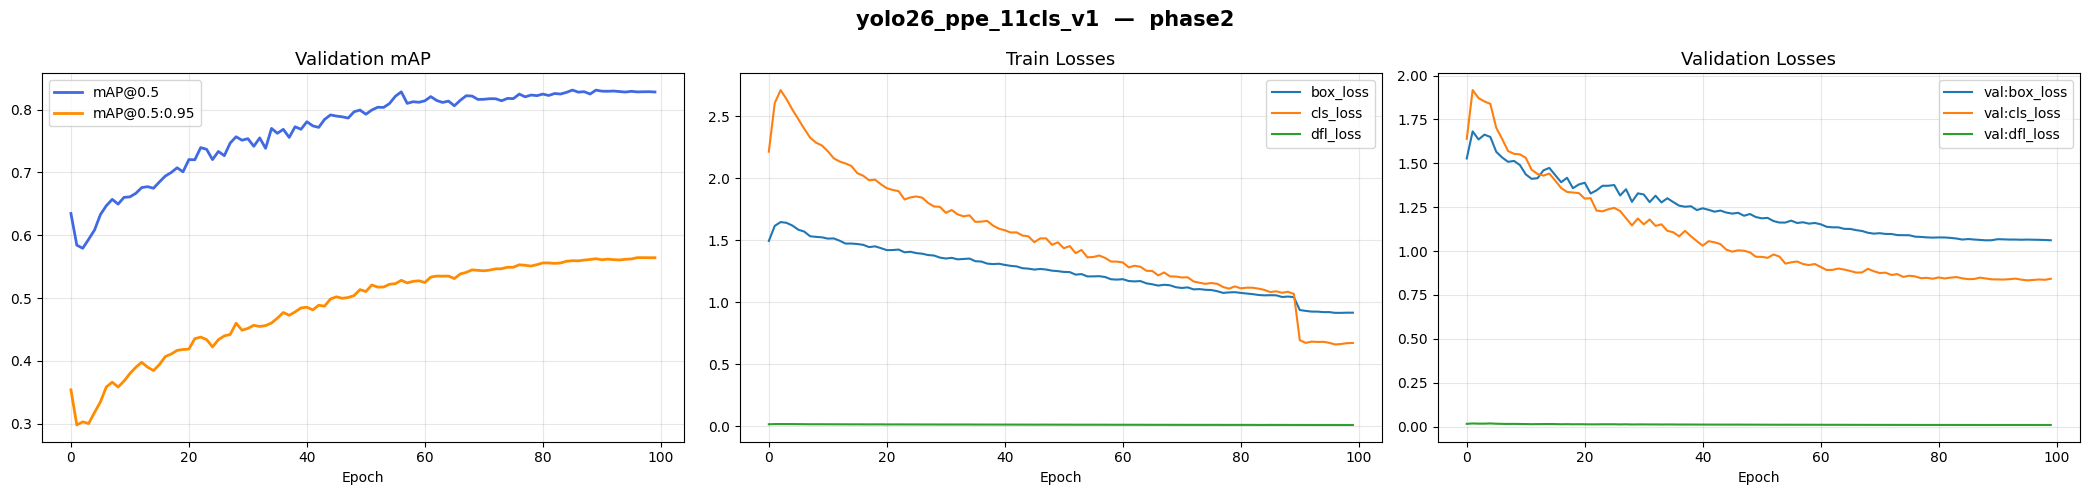

Plot saved to Drive: /content/drive/MyDrive/FINALE/Runs/yolo26_ppe_11cls_v1_phase2/training_curves.png


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import os

MONITOR_PHASE = 'phase2'   # change to 'phase1' to see Phase 1 curves

results_csv = os.path.join(
    DRIVE_RESULTS_PATH, RUN_NAME + '_' + MONITOR_PHASE, 'results.csv'
)

if not os.path.exists(results_csv):
    print('results.csv not found:', results_csv)
    print('Training may not have started yet, or MONITOR_PHASE is wrong.')
else:
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()
    epochs_done = len(df)
    print('Epochs completed:', epochs_done)

    map50_col = next((c for c in df.columns if 'mAP50(B)'    in c and '95' not in c), None)
    map95_col = next((c for c in df.columns if 'mAP50-95(B)' in c), None)

    if map50_col and len(df) > 0:
        best_epoch = int(df[map50_col].idxmax()) + 1
        best_map50 = df[map50_col].max()
        print('Best mAP@0.5     : {:.4f}  (epoch {})'.format(best_map50, best_epoch))
    if map95_col and len(df) > 0:
        print('Best mAP@0.5:0.95: {:.4f}'.format(df[map95_col].max()))

    useful = [c for c in
              ['epoch', 'train/box_loss', 'train/cls_loss',
               'val/box_loss', 'val/cls_loss']
              + ([map50_col] if map50_col else [])
              + ([map95_col] if map95_col else [])
              if c in df.columns]
    print()
    print('Last 15 epochs:')
    print(df[useful].tail(15).to_string(index=False))

    fig, axes = plt.subplots(1, 3, figsize=(21, 5))

    if map50_col: axes[0].plot(df[map50_col], label='mAP@0.5',      linewidth=2, color='royalblue')
    if map95_col: axes[0].plot(df[map95_col], label='mAP@0.5:0.95', linewidth=2, color='darkorange')
    axes[0].set_title('Validation mAP', fontsize=13)
    axes[0].set_xlabel('Epoch')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    for col in [c for c in df.columns if 'train' in c and 'loss' in c.lower()]:
        axes[1].plot(df[col], label=col.replace('train/', ''), linewidth=1.5)
    axes[1].set_title('Train Losses', fontsize=13)
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    for col in [c for c in df.columns if 'val/' in c and 'loss' in c.lower()]:
        axes[2].plot(df[col], label=col.replace('val/', 'val:'), linewidth=1.5)
    axes[2].set_title('Validation Losses', fontsize=13)
    axes[2].set_xlabel('Epoch')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.suptitle(RUN_NAME + '  —  ' + MONITOR_PHASE, fontsize=15, fontweight='bold')
    plt.tight_layout()

    out_png = os.path.join(DRIVE_RESULTS_PATH, RUN_NAME + '_' + MONITOR_PHASE, 'training_curves.png')
    plt.savefig(out_png, dpi=150, bbox_inches='tight')
    plt.show()
    print('Plot saved to Drive:', out_png)


---
## ✅ Section 5 — Evaluate Best Model on Test Set

> Runs `best.pt` against the held-out test split.  
> Shows per-class AP@0.5 for all 11 classes.  
> Classes below 0.60 AP should be investigated: check for label errors or add more data.


In [6]:
from ultralytics import YOLO
import os

ALL_NAMES = [
    'Hardhat', 'Mask', 'NO-Hardhat', 'NO-Mask',
    'NO-Safety Vest', 'Person', 'Safety Vest',
    'Safety-boots', 'NO-Safety-boots',
    'Gloves', 'NO-Gloves',
]

p2_best = os.path.join(DRIVE_RESULTS_PATH, RUN_NAME + '_phase2', 'weights', 'best.pt')
p1_best = os.path.join(DRIVE_RESULTS_PATH, RUN_NAME + '_phase1', 'weights', 'best.pt')
best_pt = p2_best if os.path.exists(p2_best) else p1_best

if not os.path.exists(best_pt):
    raise FileNotFoundError(
        'best.pt not found.\n'
        'Run Section A1 + A2 first, or check RUN_NAME matches your run.'
    )

print('Evaluating:', best_pt)
print()

model   = YOLO(best_pt)
metrics = model.val(
    data      = DATA_YAML,
    imgsz     = IMGSZ,
    device    = 0,
    split     = 'test',
    plots     = True,
    save_json = True,
    verbose   = True,
)

map50   = metrics.box.map50
map9595 = metrics.box.map

print()
print('=' * 66)
print('  TEST SET RESULTS  —  11 Classes')
print('  mAP@0.5        : {:.4f}'.format(map50))
print('  mAP@0.5:0.95   : {:.4f}'.format(map9595))
print('=' * 66)
print()
print('  Per-class AP@0.5:')
print('  ' + 'Class'.ljust(22) + '  ' + 'AP@0.5'.rjust(8) + '  Status')
print('  ' + '-' * 50)

if hasattr(metrics.box, 'ap_class_index') and metrics.box.ap_class_index is not None:
    for i, cls_idx in enumerate(metrics.box.ap_class_index):
        ap   = float(metrics.box.ap50[i])
        ci   = int(cls_idx)
        name = ALL_NAMES[ci] if ci < len(ALL_NAMES) else 'class_' + str(ci)
        if   ap >= 0.80: status = '\u2713 GOOD'
        elif ap >= 0.60: status = '~ OK'
        elif ap >= 0.40: status = '! WEAK'
        else:            status = '!! POOR'
        print('  ' + name.ljust(22) + '  ' + '{:.4f}'.format(ap).rjust(8) + '  ' + status)
else:
    print('  Per-class breakdown unavailable — check ultralytics version.')
print()


Evaluating: /content/drive/MyDrive/FINALE/Runs/yolo26_ppe_11cls_v1_phase2/weights/best.pt

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
YOLO26l summary (fused): 190 layers, 24,754,221 parameters, 0 gradients, 86.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1132.6±525.5 MB/s, size: 45.9 KB)
val: Scanning /content/dataset/test/labels... 612 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 612/612 1.5Kit/s 0.4s
val: New cache created: /content/dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 39/39 2.7it/s 14.4s
                   all        612       4576      0.853      0.816      0.861      0.592
               Hardhat        348        624      0.905      0.917      0.946      0.726
                  Mask        206        274      0.901      0.923      0.963      0.754
            NO-Hardhat        161        210      0.877      0.881

---
## 📦 Section 6 — Export Model

> Exports `best.pt` to deployment formats and copies them to Drive.

| Format | Use case | Notes |
|---|---|---|
| **ONNX** | Universal — any OS, CPU or GPU | Always exported |
| **TensorRT** | NVIDIA edge GPU (Jetson, RTX) | Uncomment for fastest inference |
| **OpenVINO** | Intel CPU / iGPU | Uncomment for Intel deployment |


In [7]:
from ultralytics import YOLO
import os, shutil

p2_best = os.path.join(DRIVE_RESULTS_PATH, RUN_NAME + '_phase2', 'weights', 'best.pt')
p1_best = os.path.join(DRIVE_RESULTS_PATH, RUN_NAME + '_phase1', 'weights', 'best.pt')
best_pt = p2_best if os.path.exists(p2_best) else p1_best

if not os.path.exists(best_pt):
    raise FileNotFoundError('best.pt not found:\n  ' + best_pt)

model = YOLO(best_pt)

# ── ONNX (always exported) ────────────────────────────────────────
print('Exporting ONNX ...')
onnx_path = model.export(format='onnx', imgsz=IMGSZ, dynamic=False, simplify=True)
print('ONNX saved:', onnx_path)

# ── TensorRT FP16 (uncomment for NVIDIA GPU deployment) ───────────
# print('Exporting TensorRT FP16 ...')
# trt_path = model.export(format='engine', imgsz=IMGSZ, half=True)
# print('TensorRT:', trt_path)

# ── OpenVINO (uncomment for Intel CPU deployment) ─────────────────
# print('Exporting OpenVINO ...')
# ov_path = model.export(format='openvino', imgsz=IMGSZ)
# print('OpenVINO:', ov_path)

# ── Copy exports to Drive ─────────────────────────────────────────
export_dir = os.path.join(DRIVE_RESULTS_PATH, RUN_NAME + '_exports')
os.makedirs(export_dir, exist_ok=True)

shutil.copy2(best_pt, os.path.join(export_dir, 'best.pt'))
if onnx_path and os.path.exists(str(onnx_path)):
    shutil.copy2(str(onnx_path), export_dir)

print()
print('All exports saved to Drive:')
print('  ' + export_dir)
for fname in sorted(os.listdir(export_dir)):
    size_mb = os.path.getsize(os.path.join(export_dir, fname)) / 1e6
    print('  ' + fname.ljust(32) + '  {:.1f} MB'.format(size_mb))


Exporting ONNX ...
Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.20GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO26l summary (fused): 190 layers, 24,754,221 parameters, 0 gradients, 86.1 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/FINALE/Runs/yolo26_ppe_11cls_v1_phase2/weights/best.pt' with input shape (1, 3, 1280, 1280) BCHW and output shape(s) (1, 300, 6) (50.7 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 209ms
Prepared 4 packages in 3.36s
Installed 4 packages in 281ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime-gpu==1.26.0
 + onnxslim==0.1.93

requirements: AutoUpdate success ✅ 4.5s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ON

/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/torchscript_exporter/symbolic_opset11.py:954: UserWarning: Exporting aten::index operator of advanced indexing in opset 20 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.
  return opset9.index(g, self, index)


ONNX: slimming with onnxslim 0.1.93...
ONNX: export success ✅ 9.7s, saved as '/content/drive/MyDrive/FINALE/Runs/yolo26_ppe_11cls_v1_phase2/weights/best.onnx' (95.3 MB)

Export complete (13.2s)
Results saved to /content/drive/MyDrive/FINALE/Runs/yolo26_ppe_11cls_v1_phase2/weights/best.onnx
Predict:         yolo predict task=detect model=/content/drive/MyDrive/FINALE/Runs/yolo26_ppe_11cls_v1_phase2/weights/best.onnx imgsz=1280 
Validate:        yolo val task=detect model=/content/drive/MyDrive/FINALE/Runs/yolo26_ppe_11cls_v1_phase2/weights/best.onnx imgsz=1280 data=/content/dataset/data.yaml  
Visualize:       https://netron.app
ONNX saved: /content/drive/MyDrive/FINALE/Runs/yolo26_ppe_11cls_v1_phase2/weights/best.onnx

All exports saved to Drive:
  /content/drive/MyDrive/FINALE/Runs/yolo26_ppe_11cls_v1_exports
  best.onnx                         99.9 MB
  best.pt                           53.2 MB
